# Residual / Offset-Correction Policy Training

Trains a model that looks at the three camera images and predicts the
6-DoF offset between the SFP/SC connector tip and the target port
(`dx, dy, dz` in meters, `droll, dpitch, dyaw` in degrees, all expressed
in the port's own frame), using the dataset produced by
`aic_solution_policy/data_acquisition.py`.

Two models are trained on the same data:
1. **CNN + MLP regressor** — shared ResNet18 encoder over the 3 views, MLP
   head, plain MSE regression.
2. **Diffusion policy** — a conditional DDPM that denoises a random 6-DoF
   vector into the offset prediction, conditioned on the same image
   features. Useful when the offset distribution is multi-modal (e.g. the
   controller settling against a physical stop can produce non-Gaussian
   residuals) — regression averages modes away, diffusion does not.

The **target label** is computed from the *actual* (ground-truth-TF /
controller-measured) `tip_pose` and `port_pose` stored per sample, not the
commanded `offset` field — the whole reason `data_acquisition.py` records
actual poses is that impedance control may not land exactly on the
commanded pose. `offset` is kept in the dataset only for reference/debugging.


## 0. Environment setup (run in a terminal, *before* launching Jupyter)

This notebook uses a plain Python venv, independent of the ROS/pixi
workspace used by `data_acquisition.py` — the dataset (`.hdf5` files) is
the only thing the two share.

```bash
cd ~/ws_aic/src/aic/aic_solution/aic_solution_policy
python3 -m venv .venv
source .venv/bin/activate
pip install --upgrade pip

# CPU-only PyTorch (simplest, works everywhere):
pip install torch torchvision

# --- OR, for an NVIDIA GPU box, pick the matching CUDA build instead, e.g.:
# pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121

pip install h5py numpy opencv-python-headless matplotlib tqdm tensorboard jupyter ipykernel scipy

python -m ipykernel install --user --name aic-residual-policy --display-name "aic-residual-policy"
```

Then open this notebook and select the **aic-residual-policy** kernel
(VSCode: top-right kernel picker; classic Jupyter: Kernel -> Change kernel).

To watch training live, in another terminal (same venv):
```bash
source ~/ws_aic/src/aic/aic_solution/aic_solution_policy/.venv/bin/activate
tensorboard --logdir ~/ws_aic/src/aic/aic_solution/dataset/runs --port 6006
```


In [69]:
import os
import glob
import math
import random
from datetime import datetime

import numpy as np
import cv2
import h5py
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from scipy.spatial.transform import Rotation as Rot

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
from torch.utils.tensorboard import SummaryWriter

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [68]:
# --------------------------------------------------------------------------
# Config -- tweak here, nothing else in the notebook should need editing to
# do a first run once you have data under CFG["data_glob"].
# --------------------------------------------------------------------------
CFG = {
    # Shared with data_acquisition.py's default output_dir and PlugIn.py's
    # residual_model_path -- everything training-related lives under
    # src/aic/aic_solution/dataset/ so the ROS pixi env and this venv agree
    # on where to find/put things.
    "data_glob": "/home/intrinsic/ws_aic/src/aic/aic_solution/dataset/hdf5/*.hdf5",
    "cams": ["left", "center", "right"],
    "image_size": 128,          # resized to (image_size, image_size) before the CNN
    "val_fraction": 0.15,
    "split_mode": "random",     # "random" or "by_port" (leave-N-ports-out, see build_index_split)
    "seed": 42,

    "batch_size": 16,
    "num_workers": 4,
    "lr": 1e-3,
    "weight_decay": 1e-4,

    # Both training loops stop early once val loss hasn't improved for
    # `early_stop_patience` epochs, so these are just upper bounds.
    "reg_epochs": 60,
    "reg_feat_dim": 256,
    "reg_hidden": 256,

    "diff_epochs": 200,
    "diff_feat_dim": 256,
    "diff_hidden": 256,
    "diff_time_dim": 64,
    "num_diffusion_steps": 100,
    "diff_eval_samples": 16,    # samples drawn per validation input when evaluating the diffusion model

    "early_stop_patience": 30,  # stop if val loss hasn't improved for this many epochs

    # Freeze the pretrained ResNet18 backbone (only train the projection +
    # MLP/diffusion head) -- see the recommendation in section 3 for why this
    # is the sane default with a dataset this size.
    "freeze_backbone": True,

    "log_dir": "/home/intrinsic/ws_aic/src/aic/aic_solution/dataset/runs",
    "ckpt_dir": "/home/intrinsic/ws_aic/src/aic/aic_solution/dataset/checkpoints",
}

random.seed(CFG["seed"])
np.random.seed(CFG["seed"])
torch.manual_seed(CFG["seed"])

os.makedirs(CFG["log_dir"], exist_ok=True)
os.makedirs(CFG["ckpt_dir"], exist_ok=True)

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)

## 1. Dataset exploration

List what's actually in the HDF5 files, and sanity-check a few samples:
images, the commanded `offset`, and the *true* offset recomputed from the
actual `tip_pose`/`port_pose` (see `compute_relative_offset` below -- this
is the function the training target also uses).


In [70]:
def list_hdf5_files(pattern=None):
    return sorted(glob.glob(pattern or CFG["data_glob"]))


def summarize_dataset(paths):
    total = 0
    for path in paths:
        with h5py.File(path, "r", locking=False) as f:
            print(f"{path}")
            print(f"  file attrs: {dict(f.attrs)}")
            for group_name in f.keys():
                g = f[group_name]
                n = g["tip_pose"].shape[0]
                total += n
                print(f"    {group_name}: {n} samples, attrs={dict(g.attrs)}")
    print(f"\nTotal samples across {len(paths)} file(s): {total}")


hdf5_paths = list_hdf5_files()
assert hdf5_paths, f"No .hdf5 files found matching {CFG['data_glob']!r}"
summarize_dataset(hdf5_paths)

/home/intrinsic/ws_aic/src/aic/aic_solution/dataset/hdf5/sfp_dataset_20260718_062233.hdf5
  file attrs: {'cable_type': 'sfp', 'image_encoding': 'bgr8', 'offset_format': 'dx,dy,dz [m] (tip-local) + droll,dpitch,dyaw [deg] (tip-local)', 'pose_format': 'xyz_m + quat_xyzw, base_link frame'}
    nic_card_mount_0_sfp_port_0: 100 samples, attrs={'approach_height_m': np.float64(0.005), 'cable_type': 'sfp', 'offset_rpy_range_deg': np.float64(5.0), 'offset_xyz_range_m': np.float64(0.002), 'port_name': 'sfp_port_0', 'target_module_name': 'nic_card_mount_0'}
    nic_card_mount_1_sfp_port_0: 100 samples, attrs={'approach_height_m': np.float64(0.005), 'cable_type': 'sfp', 'offset_rpy_range_deg': np.float64(5.0), 'offset_xyz_range_m': np.float64(0.002), 'port_name': 'sfp_port_0', 'target_module_name': 'nic_card_mount_1'}
    nic_card_mount_2_sfp_port_0: 100 samples, attrs={'approach_height_m': np.float64(0.005), 'cable_type': 'sfp', 'offset_rpy_range_deg': np.float64(5.0), 'offset_xyz_range_m': np.fl

In [71]:
def compute_relative_offset(tip_pos, tip_quat, port_pos, port_quat):
    """The label a residual policy should predict: the tip's pose relative
    to the port, expressed in the port's own frame (so it means the same
    thing regardless of the port's orientation on the task board).

    Returns [dx, dy, dz] in meters and [droll, dpitch, dyaw] in degrees,
    concatenated into one (6,) float32 array. This is computed from the
    *actual* poses recorded by data_acquisition.py, so it captures whatever
    the impedance controller actually did, not the commanded offset.
    """
    r_port = Rot.from_quat(port_quat)
    dp_local = r_port.inv().apply(np.asarray(tip_pos) - np.asarray(port_pos))
    r_tip = Rot.from_quat(tip_quat)
    r_rel = r_port.inv() * r_tip
    rpy_deg = r_rel.as_euler("xyz", degrees=True)
    return np.concatenate([dp_local, rpy_deg]).astype(np.float32)


def load_sample(path, group_name, idx, cams=CFG["cams"]):
    with h5py.File(path, "r", locking=False) as f:
        g = f[group_name]
        images = {cam: g["images"][cam][idx] for cam in cams}
        tip_pose = g["tip_pose"][idx]
        tcp_pose = g["tcp_pose"][idx]
        port_pose = g["port_pose"][idx]
        offset_cmd = g["offset"][idx]
    true_offset = compute_relative_offset(tip_pose[:3], tip_pose[3:], port_pose[:3], port_pose[3:])
    return {
        "images": images,
        "tip_pose": tip_pose,
        "tcp_pose": tcp_pose,
        "port_pose": port_pose,
        "offset_cmd": offset_cmd,
        "true_offset": true_offset,
    }


def plot_sample(sample, title=""):
    cams = list(sample["images"].keys())
    fig, axes = plt.subplots(1, len(cams), figsize=(5 * len(cams), 4))
    for ax, cam in zip(axes, cams):
        img_rgb = cv2.cvtColor(sample["images"][cam], cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
        ax.set_title(cam)
        ax.axis("off")
    off_cmd = sample["offset_cmd"]
    off_true = sample["true_offset"]
    fig.suptitle(
        f"{title}\n"
        f"commanded offset: dxyz=({off_cmd[0]*1e3:.2f},{off_cmd[1]*1e3:.2f},{off_cmd[2]*1e3:.2f})mm  "
        f"rpy=({off_cmd[3]:.1f},{off_cmd[4]:.1f},{off_cmd[5]:.1f})deg\n"
        f"actual (true) offset: dxyz=({off_true[0]*1e3:.2f},{off_true[1]*1e3:.2f},{off_true[2]*1e3:.2f})mm  "
        f"rpy=({off_true[3]:.1f},{off_true[4]:.1f},{off_true[5]:.1f})deg",
        fontsize=10,
    )
    plt.tight_layout()
    plt.show()

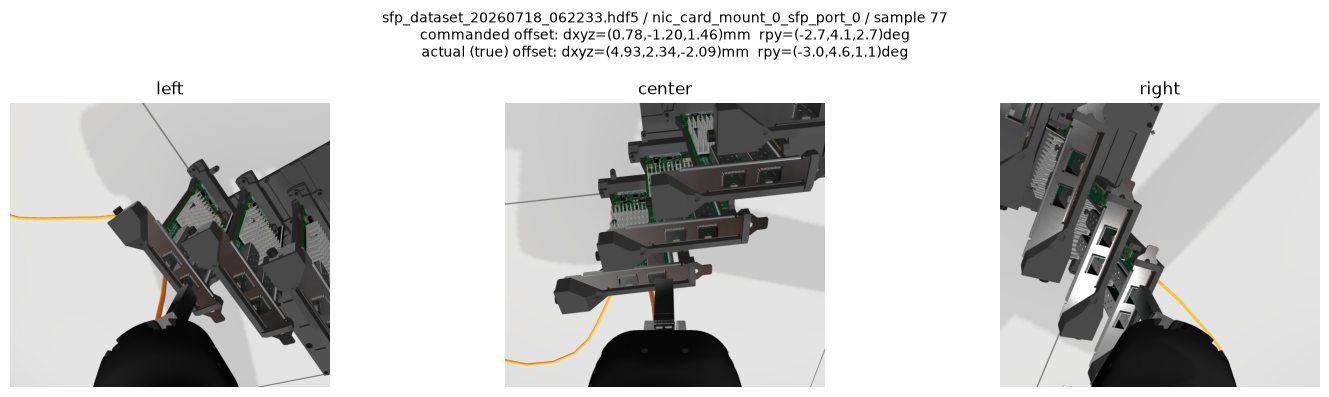

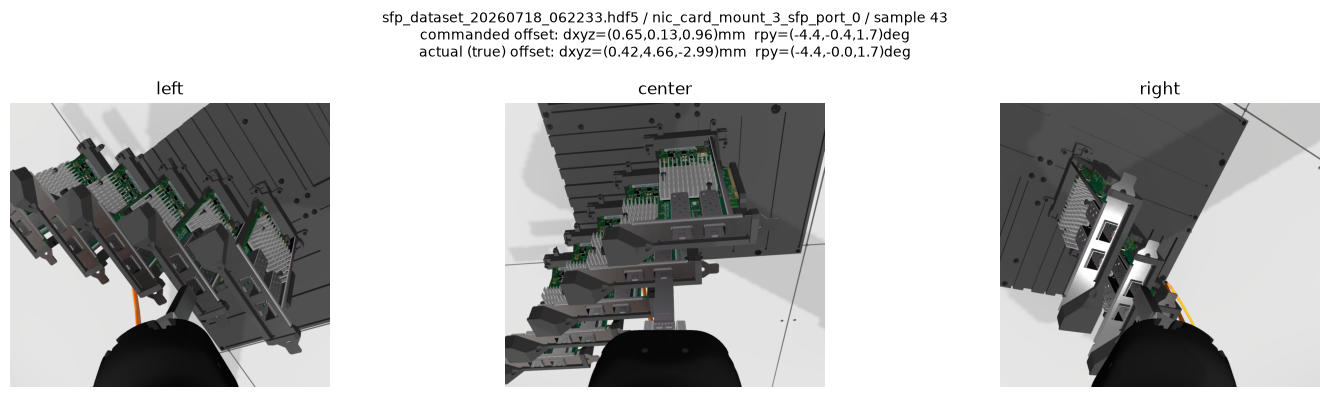

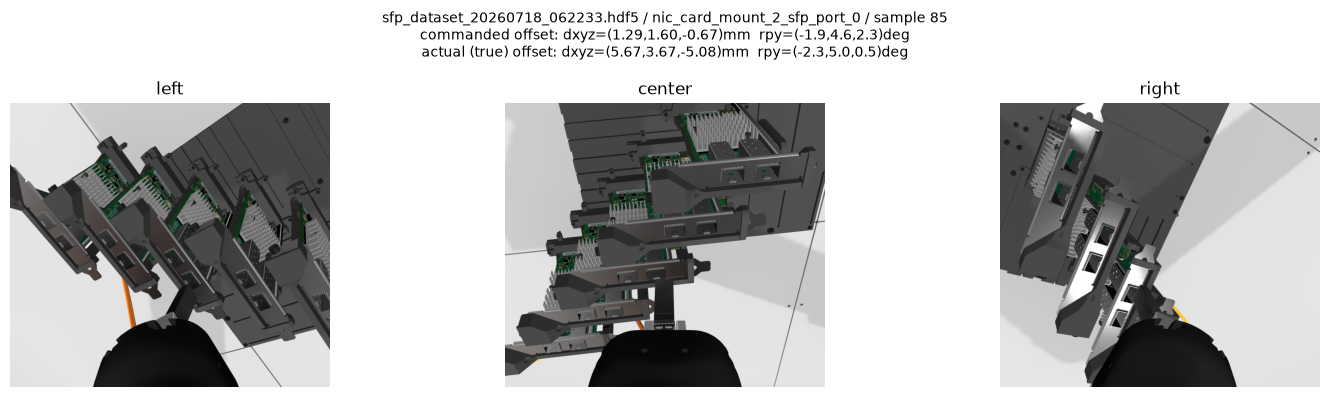

In [72]:
# Show a handful of random samples across the available files/ports.
rng = np.random.default_rng(CFG["seed"])
for _ in range(3):
    path = rng.choice(hdf5_paths)
    with h5py.File(path, "r", locking=False) as f:
        group_name = rng.choice(list(f.keys()))
        n = f[group_name]["tip_pose"].shape[0]
    idx = int(rng.integers(0, n))
    sample = load_sample(path, group_name, idx)
    plot_sample(sample, title=f"{os.path.basename(path)} / {group_name} / sample {idx}")

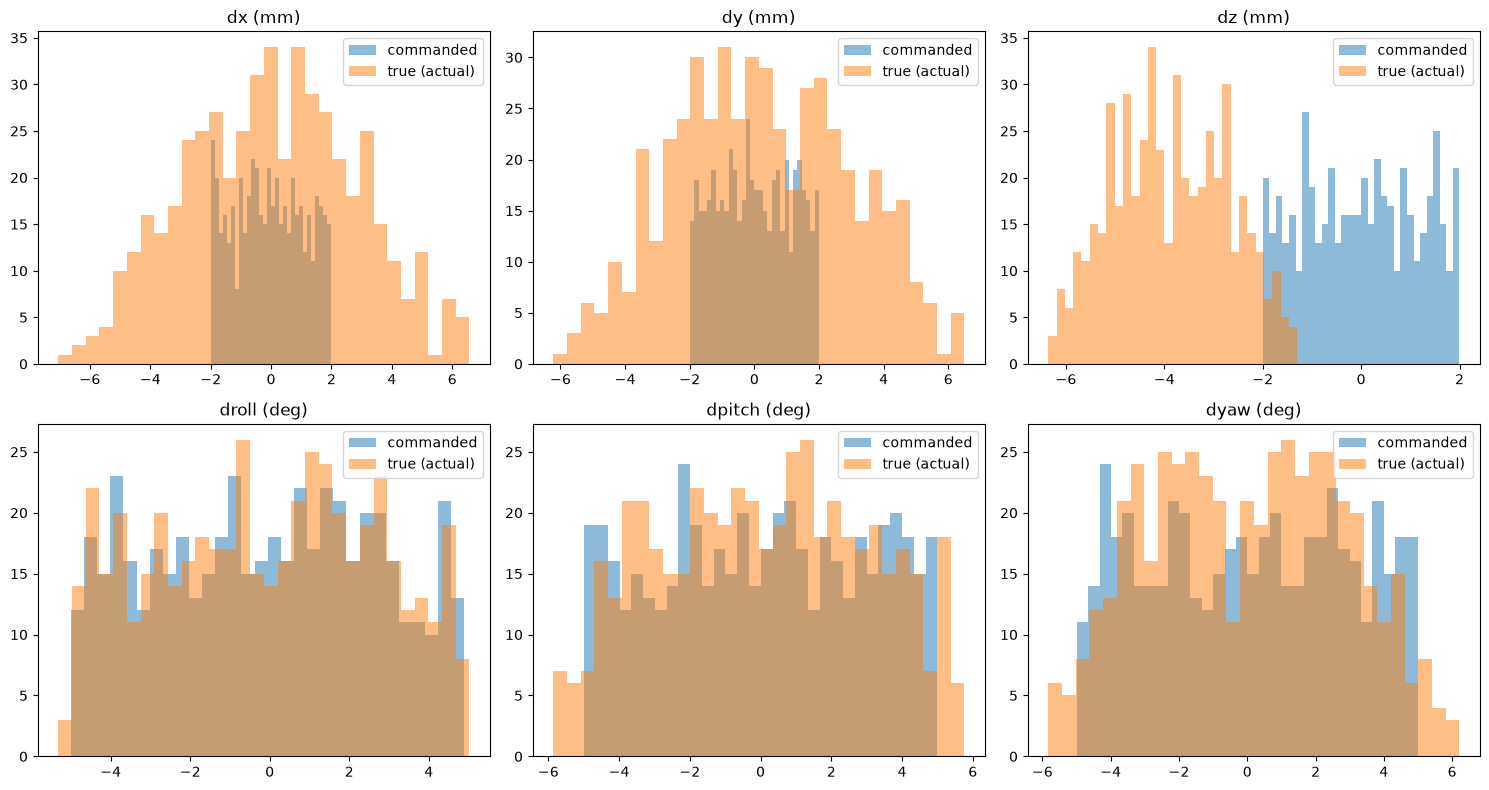

Total samples: 500
True-offset mean/std per dim: [ 1.8700544e-05  2.5903265e-04 -3.8606264e-03 -7.9503469e-02
  8.1598155e-02  2.8920688e-03] [2.8003932e-03 2.6899010e-03 1.1588705e-03 2.7681453e+00 2.9329057e+00
 2.8194666e+00]


In [73]:
# Sanity-check the offset distributions: commanded vs. actual (true). If the
# controller tracked perfectly these would coincide -- the spread between
# them is exactly the "impedance control could be a little off" slack that
# motivates using true_offset as the training target.
cmd_all, true_all = [], []
for path in hdf5_paths:
    with h5py.File(path, "r", locking=False) as f:
        for group_name in f.keys():
            g = f[group_name]
            n = g["tip_pose"].shape[0]
            cmd_all.append(g["offset"][:])
            tip = g["tip_pose"][:]
            port = g["port_pose"][:]
            true_all.append(np.stack([
                compute_relative_offset(tip[i, :3], tip[i, 3:], port[i, :3], port[i, 3:])
                for i in range(n)
            ]))
cmd_all = np.concatenate(cmd_all, axis=0)
true_all = np.concatenate(true_all, axis=0)

dim_names = ["dx (mm)", "dy (mm)", "dz (mm)", "droll (deg)", "dpitch (deg)", "dyaw (deg)"]
scale = np.array([1e3, 1e3, 1e3, 1.0, 1.0, 1.0])

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, ax in enumerate(axes.flat):
    ax.hist(cmd_all[:, i] * scale[i], bins=30, alpha=0.5, label="commanded")
    ax.hist(true_all[:, i] * scale[i], bins=30, alpha=0.5, label="true (actual)")
    ax.set_title(dim_names[i])
    ax.legend()
plt.tight_layout()
plt.show()

print(f"Total samples: {len(true_all)}")
print("True-offset mean/std per dim:", true_all.mean(0), true_all.std(0))

## 2. PyTorch `Dataset` / `DataLoader`

`OffsetDataset` opens its HDF5 files lazily (on first `__getitem__` call in
each worker process), which is required for `DataLoader(num_workers>0)`:
`h5py.File` handles aren't safe to open before the worker processes fork.


In [74]:
def build_flat_index(paths):
    """List of (path, group_name, sample_idx) for every sample across every
    file/port, plus the port id each entry belongs to (for by-port splits)."""
    index, port_ids = [], []
    for path in paths:
        with h5py.File(path, "r", locking=False) as f:
            for group_name in f.keys():
                n = f[group_name]["tip_pose"].shape[0]
                for i in range(n):
                    index.append((path, group_name, i))
                    port_ids.append(group_name)
    return index, port_ids


def split_index(index, port_ids, val_fraction, split_mode, seed):
    rng = np.random.default_rng(seed)
    n = len(index)
    if split_mode == "by_port":
        unique_ports = sorted(set(port_ids))
        if len(unique_ports) < 2:
            print(f"by_port split needs >=2 ports, only found {unique_ports}; falling back to random split")
            perm = rng.permutation(n)
            n_val = round(n * val_fraction)
            return [index[i] for i in perm[n_val:]], [index[i] for i in perm[:n_val]]
        n_val_ports = min(len(unique_ports) - 1, max(1, round(len(unique_ports) * val_fraction)))
        val_ports = set(rng.choice(unique_ports, size=n_val_ports, replace=False))
        train_idx = [i for i in range(n) if port_ids[i] not in val_ports]
        val_idx = [i for i in range(n) if port_ids[i] in val_ports]
        print(f"by_port split -- val ports: {sorted(val_ports)}")
    else:
        perm = rng.permutation(n)
        n_val = round(n * val_fraction)
        val_idx = perm[:n_val].tolist()
        train_idx = perm[n_val:].tolist()
    return [index[i] for i in train_idx], [index[i] for i in val_idx]


class OffsetDataset(Dataset):
    def __init__(self, index, image_size, cams, target_mean=None, target_std=None):
        self.index = index
        self.image_size = image_size
        self.cams = cams
        self.target_mean = target_mean
        self.target_std = target_std
        self._files = {}

    def _file(self, path):
        f = self._files.get(path)
        if f is None:
            f = h5py.File(path, "r", locking=False)
            self._files[path] = f
        return f

    def __len__(self):
        return len(self.index)

    def _load_image(self, raw_bgr):
        img = cv2.cvtColor(raw_bgr, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.image_size, self.image_size), interpolation=cv2.INTER_AREA)
        img = img.astype(np.float32) / 255.0
        img = (img - IMAGENET_MEAN) / IMAGENET_STD
        return torch.from_numpy(img.transpose(2, 0, 1))

    def __getitem__(self, i):
        path, group_name, idx = self.index[i]
        g = self._file(path)[group_name]

        images = torch.stack([self._load_image(g["images"][cam][idx]) for cam in self.cams], dim=0)

        tip_pose = g["tip_pose"][idx]
        port_pose = g["port_pose"][idx]
        target = compute_relative_offset(tip_pose[:3], tip_pose[3:], port_pose[:3], port_pose[3:])
        if self.target_mean is not None:
            target = (target - self.target_mean) / self.target_std
        return images, torch.from_numpy(target.astype(np.float32))


def compute_target_stats(index, cams):
    """Mean/std of the raw (physical-unit) target over `index`, used to
    standardize regression targets so all 6 dims contribute comparably to
    the loss (translation is in meters, rotation in degrees)."""
    raw_ds = OffsetDataset(index, image_size=CFG["image_size"], cams=cams)
    targets = np.stack([raw_ds[i][1].numpy() for i in range(len(raw_ds))])
    return targets.mean(0).astype(np.float32), targets.std(0).astype(np.float32)


def unnormalize(x, mean, std):
    mean_t = torch.as_tensor(mean, dtype=x.dtype, device=x.device)
    std_t = torch.as_tensor(std, dtype=x.dtype, device=x.device)
    return x * std_t + mean_t

In [75]:
flat_index, port_ids = build_flat_index(hdf5_paths)
train_index, val_index = split_index(flat_index, port_ids, CFG["val_fraction"], CFG["split_mode"], CFG["seed"])
print(f"train samples: {len(train_index)}  val samples: {len(val_index)}")

TARGET_MEAN, TARGET_STD = compute_target_stats(train_index, CFG["cams"])
print("target mean:", TARGET_MEAN)
print("target std: ", TARGET_STD)

train_ds = OffsetDataset(train_index, CFG["image_size"], CFG["cams"], TARGET_MEAN, TARGET_STD)
val_ds = OffsetDataset(val_index, CFG["image_size"], CFG["cams"], TARGET_MEAN, TARGET_STD)

train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"], shuffle=True,
                           num_workers=CFG["num_workers"], pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=CFG["batch_size"], shuffle=False,
                         num_workers=CFG["num_workers"], pin_memory=True)

_imgs, _tgt = train_ds[0]
print("image batch item shape:", _imgs.shape, "target shape:", _tgt.shape)

train samples: 425  val samples: 75
target mean: [ 3.1588646e-05  3.0248915e-04 -3.8609083e-03 -1.4795332e-01
  1.1207190e-01  2.0450305e-02]
target std:  [2.8167004e-03 2.6550412e-03 1.1617943e-03 2.7505381e+00 2.9309678e+00
 2.8304696e+00]
image batch item shape: torch.Size([3, 3, 128, 128]) target shape: torch.Size([6])


## 3. Model 1 -- CNN + MLP regressor (MSE)

A small ResNet18 backbone (ImageNet-pretrained) is shared (weight-tied)
across the 3 camera views; the concatenated per-view features feed an MLP
that regresses the standardized 6-DoF target, trained with Adam(W) + MSE.

**Freeze or fine-tune the pretrained backbone?** With a dataset this size
(hundreds to low thousands of samples per port), fine-tuning all of
ResNet18 risks overfitting its features to this specific simulated scene
and mostly wastes compute -- the generic ImageNet low-level features (edges,
textures, gradients) already transfer well to recognizing a connector/port.
`CFG["freeze_backbone"] = True` freezes the backbone (including its
BatchNorm running stats) and only trains the projection layer + MLP head, a
"linear probe" on top of frozen features; this is the recommended default
here. Once you have substantially more data (more ports, more randomized
lighting/backgrounds), it's worth setting it to `False` to let the backbone
adapt beyond generic ImageNet features -- watch the val loss in TensorBoard
when you do, fine-tuning overfits faster than the frozen setup.


In [76]:
class SharedViewEncoder(nn.Module):
    def __init__(self, out_dim, pretrained=True, freeze_backbone=False):
        super().__init__()
        weights = torchvision.models.ResNet18_Weights.DEFAULT if pretrained else None
        backbone = torchvision.models.resnet18(weights=weights)
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.proj = nn.Linear(512, out_dim)

        self.freeze_backbone = freeze_backbone
        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False
            self.backbone.eval()

    def train(self, mode=True):
        super().train(mode)
        if self.freeze_backbone:
            self.backbone.eval()  # keep frozen BatchNorm running stats fixed
        return self

    def forward(self, x):
        return self.proj(self.backbone(x))


class MultiViewRegressor(nn.Module):
    def __init__(self, num_cams, feat_dim, hidden, out_dim=6, freeze_backbone=False):
        super().__init__()
        self.num_cams = num_cams
        self.encoder = SharedViewEncoder(feat_dim, freeze_backbone=freeze_backbone)
        self.mlp = nn.Sequential(
            nn.Linear(feat_dim * num_cams, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, out_dim),
        )

    def forward(self, images):
        # images: (B, num_cams, 3, H, W)
        b, n, c, h, w = images.shape
        feats = self.encoder(images.reshape(b * n, c, h, w)).reshape(b, n * self.encoder.proj.out_features)
        return self.mlp(feats)

In [77]:
class EarlyStopper:
    """Stops training once val loss hasn't improved for `patience` epochs."""

    def __init__(self, patience):
        self.patience = patience
        self.best = float("inf")
        self.num_bad_epochs = 0

    def step(self, val_loss):
        if val_loss < self.best:
            self.best = val_loss
            self.num_bad_epochs = 0
        else:
            self.num_bad_epochs += 1
        return self.num_bad_epochs > self.patience


def mae_per_dim(preds_phys, targets_phys):
    return (preds_phys - targets_phys).abs().mean(dim=0)


def run_regressor_epoch(model, loader, optimizer, device, train):
    model.train(train)
    total_loss, n_seen = 0.0, 0
    all_preds, all_targets = [], []
    with torch.set_grad_enabled(train):
        for images, targets in loader:
            images, targets = images.to(device), targets.to(device)
            preds = model(images)
            loss = F.mse_loss(preds, targets)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * images.size(0)
            n_seen += images.size(0)
            all_preds.append(preds.detach().cpu())
            all_targets.append(targets.detach().cpu())
    return total_loss / n_seen, torch.cat(all_preds), torch.cat(all_targets)


def train_regressor(cfg, train_loader, val_loader, target_mean, target_std, device):
    model = MultiViewRegressor(
        len(cfg["cams"]), cfg["reg_feat_dim"], cfg["reg_hidden"], freeze_backbone=cfg["freeze_backbone"]
    ).to(device)
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(trainable_params, lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg["reg_epochs"])
    early_stopper = EarlyStopper(cfg["early_stop_patience"])

    run_name = "regression_" + datetime.now().strftime("%Y%m%d_%H%M%S")
    writer = SummaryWriter(log_dir=os.path.join(cfg["log_dir"], run_name))
    ckpt_path = os.path.join(cfg["ckpt_dir"], "regressor_best.pt")

    best_val = float("inf")
    for epoch in tqdm(range(cfg["reg_epochs"]), desc="regressor"):
        train_loss, _, _ = run_regressor_epoch(model, train_loader, optimizer, device, train=True)
        val_loss, val_preds, val_targets = run_regressor_epoch(model, val_loader, optimizer, device, train=False)
        scheduler.step()

        val_preds_phys = unnormalize(val_preds, target_mean, target_std)
        val_targets_phys = unnormalize(val_targets, target_mean, target_std)
        mae = mae_per_dim(val_preds_phys, val_targets_phys)

        writer.add_scalar("loss/train", train_loss, epoch)
        writer.add_scalar("loss/val", val_loss, epoch)
        for name, value in zip(["dx_m", "dy_m", "dz_m", "droll_deg", "dpitch_deg", "dyaw_deg"], mae.tolist()):
            writer.add_scalar(f"val_mae/{name}", value, epoch)

        if val_loss < best_val:
            best_val = val_loss
            torch.save({"model": model.state_dict(), "target_mean": target_mean, "target_std": target_std}, ckpt_path)

        if epoch % 5 == 0 or epoch == cfg["reg_epochs"] - 1:
            print(f"[regressor] epoch {epoch:03d}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  "
                  f"mae(xyz mm)=({mae[0]*1e3:.2f},{mae[1]*1e3:.2f},{mae[2]*1e3:.2f})  "
                  f"mae(rpy deg)=({mae[3]:.2f},{mae[4]:.2f},{mae[5]:.2f})")

        if early_stopper.step(val_loss):
            print(f"[regressor] early stopping at epoch {epoch:03d} "
                  f"(no val improvement for {cfg['early_stop_patience']} epochs)")
            break

    writer.close()
    # Reload the best (not necessarily last) checkpoint, since early stopping
    # means the final epoch may already be past the point of best val loss.
    best_ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(best_ckpt["model"])
    return model, ckpt_path

In [ ]:
regressor, regressor_ckpt_path = train_regressor(CFG, train_loader, val_loader, TARGET_MEAN, TARGET_STD, DEVICE)

### 3.1 Regressor evaluation

Predicted-vs-true scatter per dimension (perfect predictions lie on the
diagonal), error histograms, and a few qualitative examples.


In [ ]:
@torch.no_grad()
def collect_predictions(model, loader, device, target_mean, target_std):
    model.eval()
    all_preds, all_targets = [], []
    for images, targets in loader:
        preds = model(images.to(device)).cpu()
        all_preds.append(preds)
        all_targets.append(targets)
    preds_phys = unnormalize(torch.cat(all_preds), target_mean, target_std).numpy()
    targets_phys = unnormalize(torch.cat(all_targets), target_mean, target_std).numpy()
    return preds_phys, targets_phys


def plot_pred_vs_true(preds_phys, targets_phys, dim_names, scale, title_prefix=""):
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    for i, ax in enumerate(axes.flat):
        p, t = preds_phys[:, i] * scale[i], targets_phys[:, i] * scale[i]
        ax.scatter(t, p, s=10, alpha=0.5)
        lims = [min(t.min(), p.min()), max(t.max(), p.max())]
        ax.plot(lims, lims, "k--", linewidth=1)
        ax.set_xlabel("true")
        ax.set_ylabel("predicted")
        ax.set_title(dim_names[i])
    fig.suptitle(f"{title_prefix} predicted vs. true")
    plt.tight_layout()
    plt.show()

    mae = np.abs(preds_phys - targets_phys).mean(0) * scale
    for name, m in zip(dim_names, mae):
        print(f"  MAE {name}: {m:.3f}")


dim_names = ["dx (mm)", "dy (mm)", "dz (mm)", "droll (deg)", "dpitch (deg)", "dyaw (deg)"]
scale = np.array([1e3, 1e3, 1e3, 1.0, 1.0, 1.0])

reg_preds_phys, reg_targets_phys = collect_predictions(regressor, val_loader, DEVICE, TARGET_MEAN, TARGET_STD)
plot_pred_vs_true(reg_preds_phys, reg_targets_phys, dim_names, scale, title_prefix="[Regressor]")

In [ ]:
# A few qualitative examples: images + predicted vs. true offset as text.
@torch.no_grad()
def show_qualitative_examples(model, dataset, device, target_mean, target_std, n=3):
    model.eval()
    rng = np.random.default_rng(CFG["seed"] + 1)
    for _ in range(n):
        i = int(rng.integers(0, len(dataset)))
        path, group_name, idx = dataset.index[i]
        images, target_norm = dataset[i]
        pred_norm = model(images.unsqueeze(0).to(device)).cpu()[0]
        pred_phys = unnormalize(pred_norm, target_mean, target_std).numpy()
        true_phys = unnormalize(target_norm, target_mean, target_std).numpy()

        raw = load_sample(path, group_name, idx)
        plot_sample(
            {**raw, "offset_cmd": raw["offset_cmd"], "true_offset": true_phys},
            title=(
                f"{os.path.basename(path)} / {group_name} / sample {idx}\n"
                f"PREDICTED: dxyz=({pred_phys[0]*1e3:.2f},{pred_phys[1]*1e3:.2f},{pred_phys[2]*1e3:.2f})mm "
                f"rpy=({pred_phys[3]:.1f},{pred_phys[4]:.1f},{pred_phys[5]:.1f})deg"
            ),
        )


show_qualitative_examples(regressor, val_ds, DEVICE, TARGET_MEAN, TARGET_STD)

## 4. Model 2 -- Diffusion policy

A conditional DDPM (Ho et al. 2020) over the 6-DoF offset vector: instead
of directly regressing the offset, the model learns to denoise a random
vector into the offset, conditioned on the same multi-view image features.
Regression to MSE effectively predicts the *mean* of the target
distribution; diffusion can represent multi-modal distributions instead
(useful if, e.g., the connector can settle against either side of a
mechanical stop). Uses the same `CFG["freeze_backbone"]` and
`CFG["early_stop_patience"]` settings as the regressor above.


In [78]:
def make_beta_schedule(num_steps, beta_start=1e-4, beta_end=2e-2):
    return torch.linspace(beta_start, beta_end, num_steps)


class DiffusionSchedule:
    def __init__(self, num_steps, device):
        self.num_steps = num_steps
        self.betas = make_beta_schedule(num_steps).to(device)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)

    def q_sample(self, x0, t, noise):
        s1 = self.sqrt_alphas_cumprod[t].unsqueeze(-1)
        s2 = self.sqrt_one_minus_alphas_cumprod[t].unsqueeze(-1)
        return s1 * x0 + s2 * noise


def timestep_embedding(t, dim):
    half = dim // 2
    freqs = torch.exp(-math.log(10000.0) * torch.arange(half, device=t.device, dtype=torch.float32) / half)
    args = t.float().unsqueeze(1) * freqs.unsqueeze(0)
    emb = torch.cat([torch.sin(args), torch.cos(args)], dim=1)
    if dim % 2 == 1:
        emb = F.pad(emb, (0, 1))
    return emb


class DiffusionActionModel(nn.Module):
    def __init__(self, num_cams, feat_dim, hidden, time_dim, action_dim=6, freeze_backbone=False):
        super().__init__()
        self.num_cams = num_cams
        self.time_dim = time_dim
        self.encoder = SharedViewEncoder(feat_dim, freeze_backbone=freeze_backbone)
        cond_dim = feat_dim * num_cams
        self.net = nn.Sequential(
            nn.Linear(action_dim + cond_dim + time_dim, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, action_dim),
        )

    def encode_images(self, images):
        b, n, c, h, w = images.shape
        return self.encoder(images.reshape(b * n, c, h, w)).reshape(b, n * self.encoder.proj.out_features)

    def forward(self, x_t, t, cond_feats):
        temb = timestep_embedding(t, self.time_dim)
        return self.net(torch.cat([x_t, cond_feats, temb], dim=1))

In [79]:
def run_diffusion_epoch(model, schedule, loader, optimizer, device, train):
    model.train(train)
    total_loss, n_seen = 0.0, 0
    with torch.set_grad_enabled(train):
        for images, targets in loader:
            images, targets = images.to(device), targets.to(device)
            cond = model.encode_images(images)
            t = torch.randint(0, schedule.num_steps, (targets.size(0),), device=device)
            noise = torch.randn_like(targets)
            x_t = schedule.q_sample(targets, t, noise)
            eps_hat = model(x_t, t, cond)
            loss = F.mse_loss(eps_hat, noise)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * images.size(0)
            n_seen += images.size(0)
    return total_loss / n_seen


@torch.no_grad()
def diffusion_sample(model, schedule, images, device, num_samples):
    """DDPM ancestral sampling. Returns (B, num_samples, action_dim)."""
    model.eval()
    images = images.to(device)
    b = images.size(0)
    cond = model.encode_images(images).repeat_interleave(num_samples, dim=0)

    x = torch.randn(b * num_samples, 6, device=device)
    for t in reversed(range(schedule.num_steps)):
        t_batch = torch.full((x.size(0),), t, device=device, dtype=torch.long)
        eps_hat = model(x, t_batch, cond)
        alpha = schedule.alphas[t]
        alpha_bar = schedule.alphas_cumprod[t]
        beta = schedule.betas[t]
        mean = (x - beta / torch.sqrt(1.0 - alpha_bar) * eps_hat) / torch.sqrt(alpha)
        if t > 0:
            x = mean + torch.sqrt(beta) * torch.randn_like(x)
        else:
            x = mean
    return x.view(b, num_samples, 6)


def train_diffusion(cfg, train_loader, val_loader, target_mean, target_std, device):
    model = DiffusionActionModel(
        len(cfg["cams"]), cfg["diff_feat_dim"], cfg["diff_hidden"], cfg["diff_time_dim"],
        freeze_backbone=cfg["freeze_backbone"],
    ).to(device)
    schedule = DiffusionSchedule(cfg["num_diffusion_steps"], device)
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(trainable_params, lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg["diff_epochs"])
    early_stopper = EarlyStopper(cfg["early_stop_patience"])

    run_name = "diffusion_" + datetime.now().strftime("%Y%m%d_%H%M%S")
    writer = SummaryWriter(log_dir=os.path.join(cfg["log_dir"], run_name))
    ckpt_path = os.path.join(cfg["ckpt_dir"], "diffusion_best.pt")

    best_val = float("inf")
    for epoch in tqdm(range(cfg["diff_epochs"]), desc="diffusion"):
        train_loss = run_diffusion_epoch(model, schedule, train_loader, optimizer, device, train=True)
        val_loss = run_diffusion_epoch(model, schedule, val_loader, optimizer, device, train=False)
        scheduler.step()

        writer.add_scalar("loss/train", train_loss, epoch)
        writer.add_scalar("loss/val", val_loss, epoch)

        if val_loss < best_val:
            best_val = val_loss
            torch.save({"model": model.state_dict(), "target_mean": target_mean, "target_std": target_std}, ckpt_path)

        if epoch % 5 == 0 or epoch == cfg["diff_epochs"] - 1:
            print(f"[diffusion] epoch {epoch:03d}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}")

        if early_stopper.step(val_loss):
            print(f"[diffusion] early stopping at epoch {epoch:03d} "
                  f"(no val improvement for {cfg['early_stop_patience']} epochs)")
            break

    writer.close()
    best_ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(best_ckpt["model"])
    return model, schedule, ckpt_path

In [80]:
diffusion_model, diffusion_schedule, diffusion_ckpt_path = train_diffusion(
    CFG, train_loader, val_loader, TARGET_MEAN, TARGET_STD, DEVICE
)

diffusion:   0%|          | 0/200 [00:00<?, ?it/s]

[diffusion] epoch 000  train_loss=1.0852  val_loss=1.1489
[diffusion] epoch 005  train_loss=1.0261  val_loss=0.9126
[diffusion] epoch 010  train_loss=0.9905  val_loss=0.9856
[diffusion] epoch 015  train_loss=0.9811  val_loss=1.0189
[diffusion] epoch 020  train_loss=1.0089  val_loss=1.0473
[diffusion] epoch 025  train_loss=1.0247  val_loss=0.9916
[diffusion] epoch 030  train_loss=1.0092  val_loss=1.0612
[diffusion] epoch 035  train_loss=0.9937  val_loss=1.1059
[diffusion] epoch 040  train_loss=1.0172  val_loss=0.9699
[diffusion] early stopping at epoch 043 (no val improvement for 30 epochs)


### 4.1 Diffusion evaluation

Draws `diff_eval_samples` samples per validation input; the mean across
samples is used as the point estimate (comparable to the regressor), and
the spread indicates the model's uncertainty for that input.


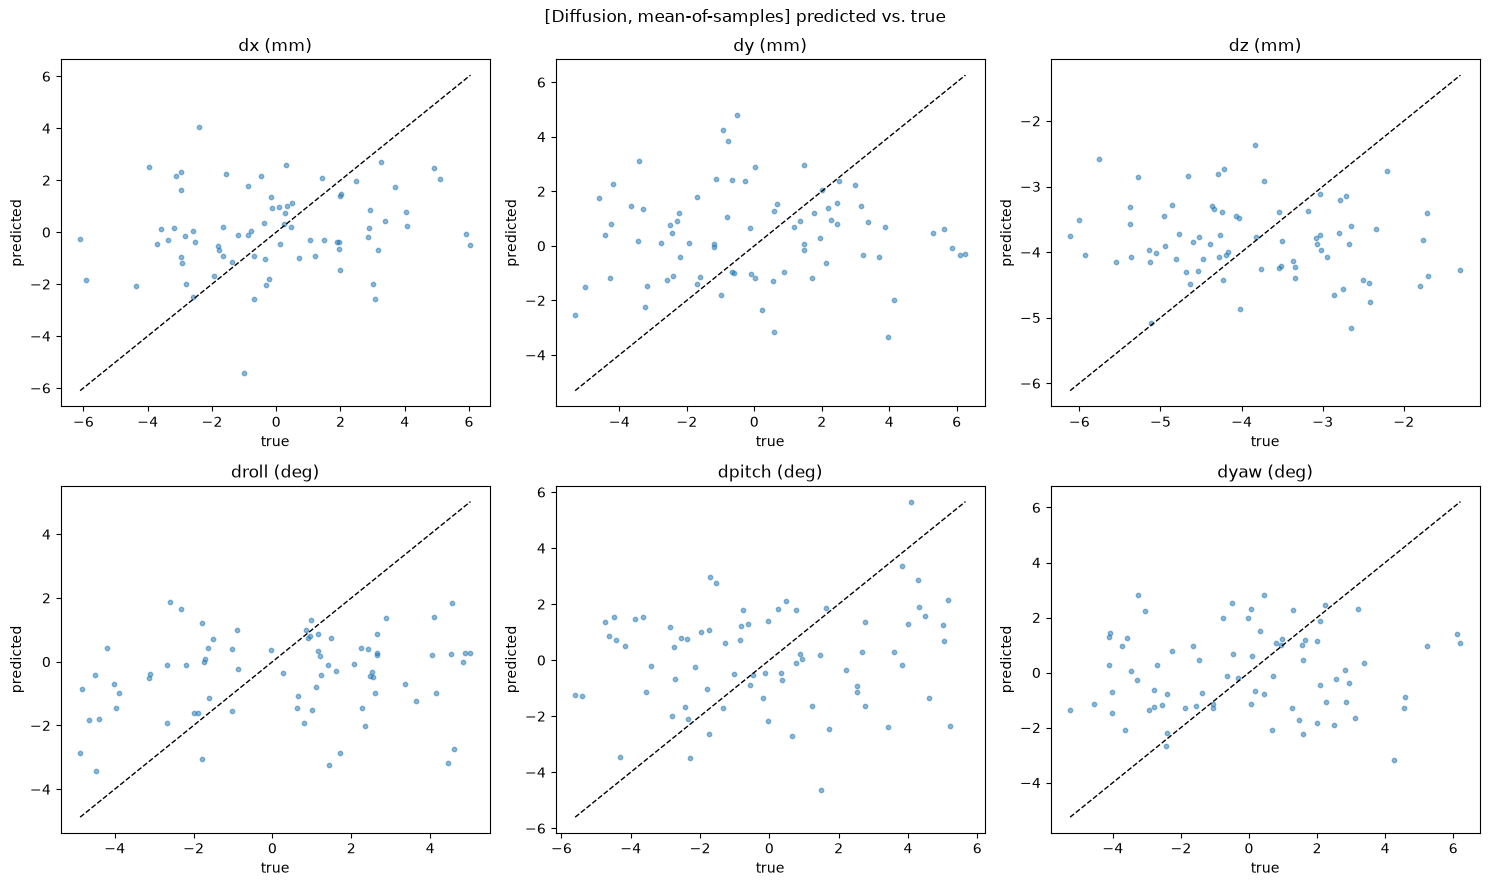

  MAE dx (mm): 2.342
  MAE dy (mm): 2.733
  MAE dz (mm): 1.125
  MAE droll (deg): 2.508
  MAE dpitch (deg): 2.670
  MAE dyaw (deg): 2.456

Mean predictive std (uncertainty) per dim, in the same units as MAE above:
  dx (mm): 6.006
  dy (mm): 5.479
  dz (mm): 2.418
  droll (deg): 5.857
  dpitch (deg): 6.237
  dyaw (deg): 6.234


In [81]:
@torch.no_grad()
def collect_diffusion_predictions(model, schedule, loader, device, target_mean, target_std, num_samples):
    all_mean_preds, all_stds, all_targets = [], [], []
    for images, targets in loader:
        samples = diffusion_sample(model, schedule, images, device, num_samples)  # (B, S, 6)
        all_mean_preds.append(samples.mean(dim=1).cpu())
        all_stds.append(samples.std(dim=1).cpu())
        all_targets.append(targets)
    mean_preds = unnormalize(torch.cat(all_mean_preds), target_mean, target_std).numpy()
    stds_phys = (torch.cat(all_stds) * torch.as_tensor(target_std)).numpy()
    targets_phys = unnormalize(torch.cat(all_targets), target_mean, target_std).numpy()
    return mean_preds, stds_phys, targets_phys


diff_preds_phys, diff_stds_phys, diff_targets_phys = collect_diffusion_predictions(
    diffusion_model, diffusion_schedule, val_loader, DEVICE, TARGET_MEAN, TARGET_STD, CFG["diff_eval_samples"]
)
plot_pred_vs_true(diff_preds_phys, diff_targets_phys, dim_names, scale, title_prefix="[Diffusion, mean-of-samples]")

print("\nMean predictive std (uncertainty) per dim, in the same units as MAE above:")
for name, s in zip(dim_names, diff_stds_phys.mean(0) * scale):
    print(f"  {name}: {s:.3f}")

## 5. Regressor vs. diffusion -- summary

Same validation set, same units, so the MAE numbers above are directly
comparable. If the diffusion model's per-dim predictive std stays small
and its MAE is close to the regressor's, the residual distribution is
likely close to unimodal and the (much cheaper to run) regressor is the
better default; large std or a clear MAE edge for diffusion indicates real
multi-modality worth keeping the diffusion model for.


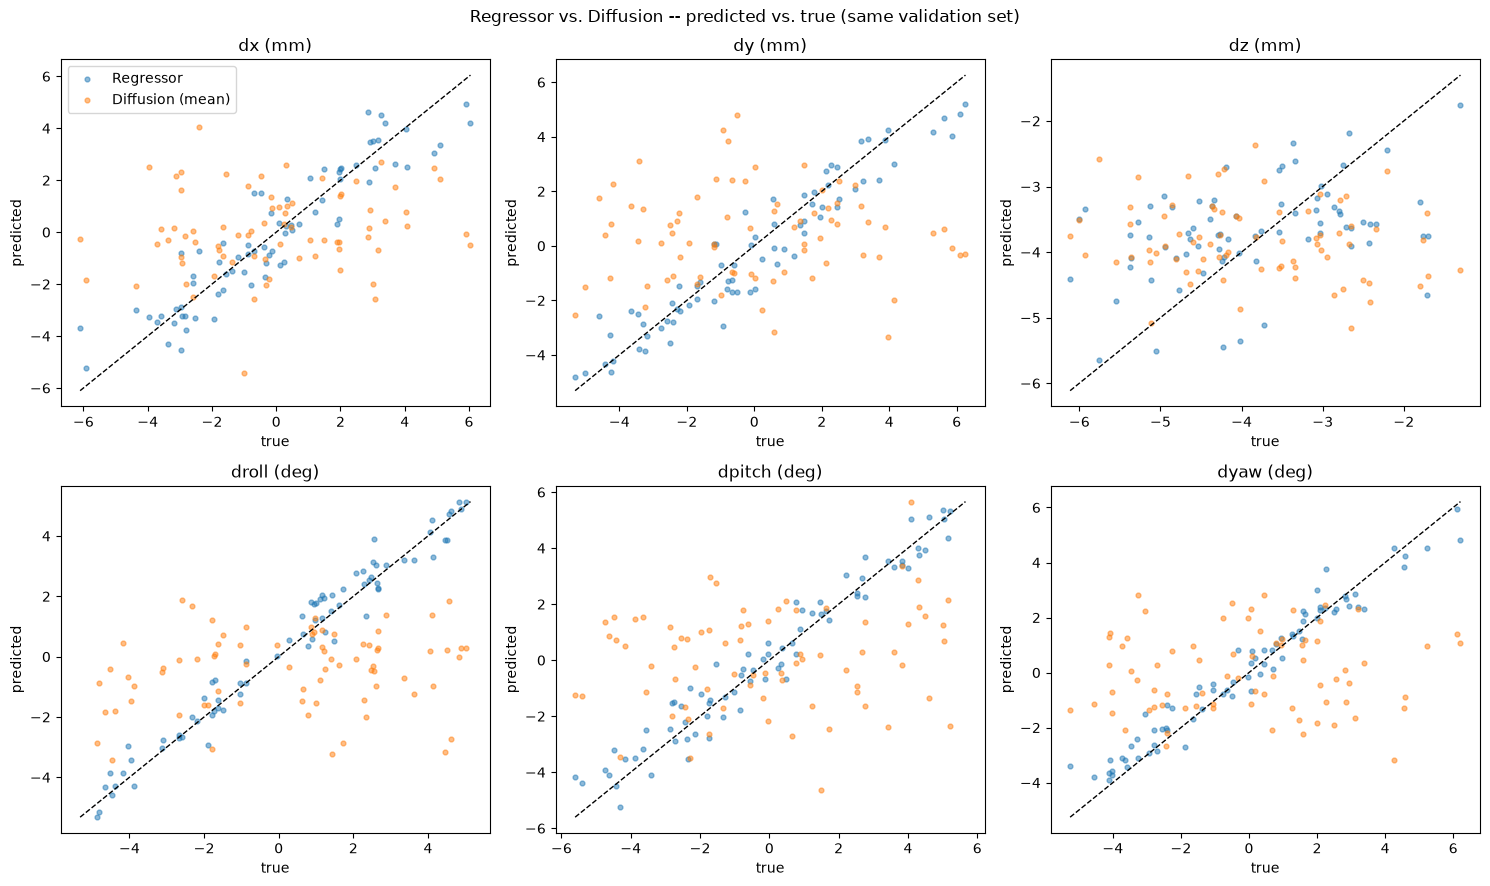

In [82]:
def plot_pred_vs_true_combined(preds_by_model, targets_phys, dim_names, scale):
    """Overlays each model's predicted-vs-true scatter (different color per
    model, same axes) so their spread/bias can be compared directly."""
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    for i, ax in enumerate(axes.flat):
        t = targets_phys[:, i] * scale[i]
        all_vals = [t]
        for (label, preds_phys), color in zip(preds_by_model.items(), colors):
            p = preds_phys[:, i] * scale[i]
            ax.scatter(t, p, s=12, alpha=0.5, label=label, color=color)
            all_vals.append(p)
        lims = [min(v.min() for v in all_vals), max(v.max() for v in all_vals)]
        ax.plot(lims, lims, "k--", linewidth=1)
        ax.set_xlabel("true")
        ax.set_ylabel("predicted")
        ax.set_title(dim_names[i])
        if i == 0:
            ax.legend()
    fig.suptitle("Regressor vs. Diffusion -- predicted vs. true (same validation set)")
    plt.tight_layout()
    plt.show()


# reg_targets_phys and diff_targets_phys come from the same (shuffle=False)
# val_loader, so they're the same underlying samples in the same order.
plot_pred_vs_true_combined(
    {"Regressor": reg_preds_phys, "Diffusion (mean)": diff_preds_phys},
    reg_targets_phys, dim_names, scale,
)

In [83]:
def summarize(name, preds_phys, targets_phys):
    mae = np.abs(preds_phys - targets_phys).mean(0) * scale
    rmse = np.sqrt(((preds_phys - targets_phys) ** 2).mean(0)) * scale
    print(f"{name:>12s} | " + "  ".join(f"{n}: MAE={m:.3f} RMSE={r:.3f}" for n, m, r in zip(dim_names, mae, rmse)))


summarize("Regressor", reg_preds_phys, reg_targets_phys)
summarize("Diffusion", diff_preds_phys, diff_targets_phys)

print(f"\nCheckpoints saved to: {CFG['ckpt_dir']}/")
print(f"TensorBoard logs in: {CFG['log_dir']}/  (tensorboard --logdir {CFG['log_dir']})")

   Regressor | dx (mm): MAE=0.810 RMSE=1.011  dy (mm): MAE=0.718 RMSE=0.873  dz (mm): MAE=0.878 RMSE=1.092  droll (deg): MAE=0.410 RMSE=0.520  dpitch (deg): MAE=0.557 RMSE=0.678  dyaw (deg): MAE=0.484 RMSE=0.629
   Diffusion | dx (mm): MAE=2.342 RMSE=2.907  dy (mm): MAE=2.733 RMSE=3.338  dz (mm): MAE=1.125 RMSE=1.367  droll (deg): MAE=2.508 RMSE=2.984  dpitch (deg): MAE=2.670 RMSE=3.211  dyaw (deg): MAE=2.456 RMSE=3.043

Checkpoints saved to: /home/intrinsic/ws_aic/src/aic/aic_solution/dataset/checkpoints/
TensorBoard logs in: /home/intrinsic/ws_aic/src/aic/aic_solution/dataset/runs/  (tensorboard --logdir /home/intrinsic/ws_aic/src/aic/aic_solution/dataset/runs)
